## Phase 4: Statistical EDA
### Part 1: Univariate Analysis

In [2]:
import pandas as pd
import seaborn as sns

In [10]:
df_filtered = pd.read_pickle("../data/cleaned_data.pkl")
df_filtered.head()

,id,title,company_name,category_label,category_tag,country,location_display,location_area,latitude,longitude,contract_type,contract_time,salary_min,salary_max,salary_mid,salary_is_predicted,created_dt,created_date,redirect_url,adref
0,5410474609,Mechanical Pipefitter,Dodd Group,Trade & Construction Jobs,trade-construction-jobs,United Kingdom,"King's Lynn, Norfolk",UK > Eastern England > Norfolk > King's Lynn,52.751999,0.395357,permanent,full_time,40518.74,40518.74,40518.74,1,2025-09-22 09:28:13+00:00,2025-09-22,https://www.adzuna.co.uk/jobs/details/54104746...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQxMDQ3NDYwOSIsI...
1,5381519011,International Trade Policy Editor [Startup Pol...,Applio Ventures,Graduate Jobs,graduate-jobs,United Kingdom,"London, UK",UK > London,NaN,NaN,permanent,full_time,64000.00,64000.00,64000.00,0,2025-09-03 21:20:59+00:00,2025-09-03,https://www.adzuna.co.uk/jobs/details/53815190...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTM4MTUxOTAxMSIsI...
3,5403097985,Early Years BABY Room Leader,Jesters Childcare Essex,Teaching Jobs,teaching-jobs,United Kingdom,UK,UK,NaN,NaN,permanent,full_time,26707.00,29494.00,28100.50,0,2025-09-17 15:00:12+00:00,2025-09-17,https://www.adzuna.co.uk/jobs/details/54030979...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQwMzA5Nzk4NSIsI...
5,5404665589,Computer Systems Validation specialist,North Star Consulting UK,Scientific & QA Jobs,scientific-qa-jobs,United Kingdom,"Newcastle Upon Tyne, Tyne & Wear",UK > North East England > Tyne & Wear > Newcas...,NaN,NaN,permanent,full_time,65000.00,65000.00,65000.00,0,2025-09-18 10:29:32+00:00,2025-09-18,https://www.adzuna.co.uk/jobs/details/54046655...,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiRWtwZjc5cWI4QkdZM...
6,5404864465,Full Stack Software Engineer,Marshall Wolfe Ltd,IT Jobs,it-jobs,United Kingdom,UK,UK,NaN,NaN,permanent,full_time,0.00,60000.00,30000.00,0,2025-09-18 14:32:46+00:00,2025-09-18,https://www.adzuna.co.uk/jobs/details/54048644...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQwNDg2NDQ2NSIsI...


In [9]:
# View relevant statistics for salary categories
print(df_filtered.nunique())
print(df_filtered[['salary_min', 'salary_max', 'salary_mid']].describe())

id                     1345
title                  1063
company_name            624
category_label           67
category_tag             30
country                   8
location_display        964
location_area           964
latitude                963
longitude               963
contract_type             2
contract_time             2
salary_min              795
salary_max              807
salary_mid              916
salary_is_predicted       2
created_dt             1096
created_date            211
redirect_url           1345
adref                  1346
dtype: int64
          salary_min     salary_max     salary_mid
count    1346.000000    1346.000000    1346.000000
mean    47527.442578   53017.268730   50272.355654
std     35305.787348   37694.082998   35959.681985
min         0.000000    1000.000000     601.000000
25%     26028.625000   30000.000000   28000.000000
50%     38425.450000   45020.925000   41791.315000
75%     59281.612500   65000.000000   61094.892500
max    384000.00000

<Axes: xlabel='category_tag', ylabel='count'>

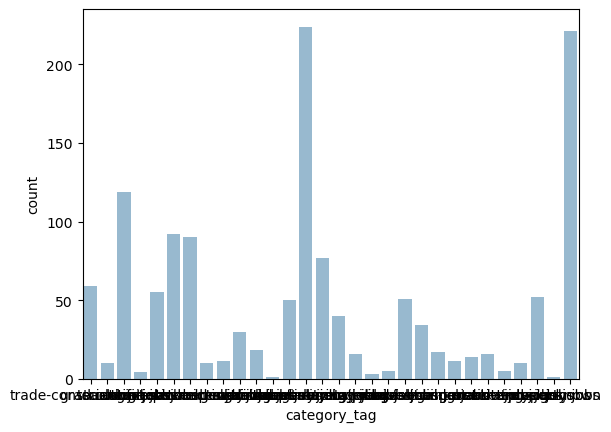

In [11]:
# Visualize the spread of job types
sns.countplot(data = df_filtered, x = 'category_tag', alpha = 0.5)

<Axes: xlabel='country', ylabel='count'>

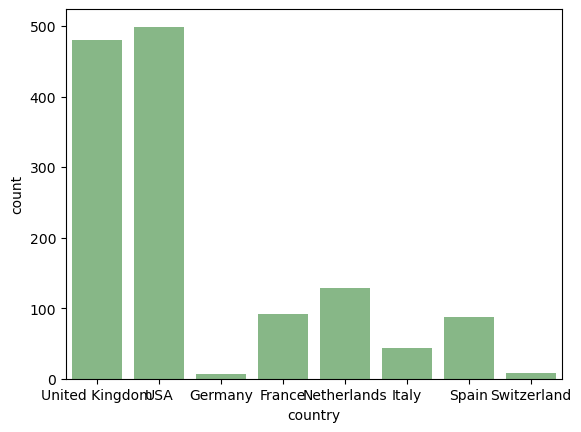

In [12]:
# Visualize the distribution of job locations
sns.countplot(data = df_filtered, x = 'country', color = 'Green', alpha = 0.5)

### Part 2: Bivariate Analysis

In [40]:
# Group salary by job type
df_job_type = df_filtered.groupby('category_tag')[['salary_min', 'salary_max', 'salary_mid']].agg(['mean', 'std', 'var'])

# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average minimum salary by job:")
df_job_type['salary_min'].sort_values(by = 'mean', ascending = False)

Descending sort of average minimum salary by job:


,mean,std,var
category_tag,,,
healthcare-nursing-jobs,81303.923080,46495.020812,2.161787e+09
accounting-finance-jobs,71100.483333,75967.892929,5.771121e+09
legal-jobs,69754.387647,46301.875898,2.143864e+09
it-jobs,64791.864000,32370.047556,1.047820e+09
travel-jobs,61821.350192,15487.669114,2.398679e+08
scientific-qa-jobs,61565.325000,16135.025710,2.603391e+08
part-time-jobs,60914.430625,42890.483824,1.839594e+09
property-jobs,60000.000000,NaN,NaN
energy-oil-gas-jobs,53185.106667,2980.926359,8.885922e+06


In [39]:
print("Descending sort of average maximum salary by job:")
df_job_type['salary_max'].sort_values(by = 'mean', ascending = False)

Descending sort of average maximum salary by job:


,mean,std,var
category_tag,,,
accounting-finance-jobs,87455.350000,93432.927392,8.729712e+09
healthcare-nursing-jobs,87134.088259,50423.392669,2.542519e+09
legal-jobs,86272.034706,46104.067059,2.125585e+09
it-jobs,71933.518545,29159.150510,8.502561e+08
scientific-qa-jobs,70815.325000,33634.967489,1.131311e+09
property-jobs,70000.000000,NaN,NaN
part-time-jobs,65769.180625,39410.555632,1.553192e+09
travel-jobs,61951.504038,15305.312497,2.342526e+08
energy-oil-gas-jobs,61585.106667,17366.094378,3.015812e+08


In [38]:
# Repeat for location
df_location = df_filtered.groupby('country')[['salary_min', 'salary_max', 'salary_mid']].agg(['mean', 'std', 'var'])

# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average minimum salary by country:")
df_location['salary_min'].sort_values(by = 'mean', ascending = False)

Descending sort of average minimum salary by country:


,mean,std,var
country,,,
USA,72953.445812,37795.429226,1.428494e+09
Germany,70428.571429,41287.032439,1.704619e+09
Switzerland,45875.000000,21675.776473,4.698393e+08
United Kingdom,36570.604688,19230.741123,3.698214e+08
Netherlands,33779.527132,19102.163210,3.648926e+08
France,28919.565217,39327.791921,1.546675e+09
Italy,17106.976744,9003.528286,8.106352e+07
Spain,15914.988636,13453.433335,1.809949e+08


In [37]:
# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average maximum salary by country:")
df_location['salary_min'].sort_values(by = 'mean', ascending = False)

Descending sort of average maximum salary by country:


,mean,std,var
country,,,
USA,72953.445812,37795.429226,1.428494e+09
Germany,70428.571429,41287.032439,1.704619e+09
Switzerland,45875.000000,21675.776473,4.698393e+08
United Kingdom,36570.604688,19230.741123,3.698214e+08
Netherlands,33779.527132,19102.163210,3.648926e+08
France,28919.565217,39327.791921,1.546675e+09
Italy,17106.976744,9003.528286,8.106352e+07
Spain,15914.988636,13453.433335,1.809949e+08


### Part 3: Multivariate Analysis